# Import

In [1]:
import numpy as np
import seaborn as sns
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import numpy as np
import plotly.graph_objs as go
from ipywidgets import widgets, HBox, VBox, Output

sns.set(style="white")

In [7]:
pip freeze

appnope==0.1.4
asttokens==3.0.0
attrs==25.1.0
certifi==2025.1.31
chardet==5.2.0
charset-normalizer==3.4.1
click==8.1.8
coinmetrics==0.2.5
coinmetrics-api-client==2025.3.3.16
colorama==0.4.6
comm==0.2.2
contourpy==1.3.1
cycler==0.12.1
debugpy==1.8.13
decorator==5.2.1
dill==0.3.9
duckdb==1.2.1
executing==2.2.0
fastjsonschema==2.21.1
fonttools==4.56.0
idna==3.10
ipykernel==6.29.5
ipython==9.0.2
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.5
jedi==0.19.2
joblib==1.4.2
jsonschema==4.23.0
jsonschema-specifications==2024.10.1
jupyter_client==8.6.3
jupyter_core==5.7.2
jupyterlab_widgets==3.0.13
kaleido==0.2.1
kiwisolver==1.4.8
mapply==0.1.27
markdown-it-py==3.0.0
matplotlib==3.10.1
matplotlib-inline==0.1.7
mdurl==0.1.2
multiprocess==0.70.17
narwhals==1.30.0
nbformat==5.10.4
nest-asyncio==1.6.0
numpy==2.2.3
orjson==3.10.15
packaging==24.2
pandas==2.2.3
parso==0.8.4
pathos==0.3.3
patsy==1.0.1
pexpect==4.9.0
pillow==11.1.0
platformdirs==4.3.6
plotly==6.0.0
polars==1.24.0
pox==0.3.5
ppft==1.7.6.

# Tools functions

In [2]:
# Generate the stock price paths
def generate_BM_path_func(**params):

    X = np.zeros((params['n_paths'], params['n_steps'] + 1))
    X[:,0] = params['S_0']
    dW = np.zeros(shape=(params['n_paths'], params['n_steps'] + 1))
    t_ = np.zeros(shape=(params['n_paths'], params['n_steps'] + 1))

    dW[:,1:] = np.random.normal(loc=0, scale=np.sqrt(params['T']/params['n_steps']), size=(params['n_paths'], params['n_steps']))
    t_[:,:] = np.linspace(0, params['T'], params['n_steps'] + 1)

    W = np.cumsum(dW, axis=1)

    X = params['S_0']*np.exp(params['sigma']*W + (params['rate']-0.5*(params['sigma']**2))*t_)

    return X, t_

In [3]:
def amm_paths_func(**params):

    a0, a1, a2, a3 = params['a0'], params['a1'], params['a2'], params['a3'] #1, 30, 0, 10

    ksi = params['ksi'] #3

    # Initialisation
    X0 = params['X0'] #10**6 # USD
    Y0 = params['Y0'] #10**3 # USD

    c = X0*Y0

    step_size = params['T']/params['n_steps']

    # Constant product function
    phi_func = lambda x : c/x
    d_phi_func = lambda x : -c/(x**2)

    # Intensity functions
    intensity_a = lambda Y, Z, S : np.maximum(a0, a1 + a2*Y + a3*(S-Z))
    intensity_b = lambda Y, Z, S : np.maximum(a0, a1 + a2*Y + a3*(Z-S))

    # Fees function
    r_fees = lambda Y, Z : 0.01*Z

    # Generate exteral stock price paths
    S, t_ = generate_BM_path_func(**params)

    X = np.zeros_like(S)
    Y = np.zeros_like(S)
    Z = np.zeros_like(S)
    R = np.zeros_like(S) # Fees function
    Na, Nb = np.zeros_like(S), np.zeros_like(S)

    Na[:, 0], Nb[:, 0] = 0, 0
    Y[:, 0] = Y0
    X[:, 0] = X0
    Z[:, 0] = X[:, 0]/Y[:, 0]

    # Generate path
    for i in range(1, params['n_steps'] + 1):

        # Update Na and Nb: Jump times
        lambda_a = intensity_a(Y[:, i-1], Z[:, i-1], S[:, i])
        lambda_b = intensity_b(Y[:, i-1], Z[:, i-1], S[:, i])

        # If 1/lambda  equivalent to step_size, maybe more than one jump during the step
        u_a = np.random.uniform(0,1, size=params['n_paths'])
        u_b = np.random.uniform(0,1, size=params['n_paths'])

        dNa_i = (u_a <= lambda_a * step_size)*1
        dNb_i = (u_b <= lambda_b * step_size)*1

        Na[:, i] = dNa_i
        Nb[:, i] = dNb_i

        Y[:, i] = Y[:, i-1] + ksi*dNb_i - ksi*dNa_i
        X[:, i] = X[:, i-1] + (phi_func(Y[:, i-1]+ksi) - phi_func(Y[:, i-1]))*dNb_i + (phi_func(Y[:, i-1]-ksi) - phi_func(Y[:, i-1]))*dNa_i
        Z[:, i] = Z[:, i-1] + (-d_phi_func(Y[:, i-1]+ksi) + d_phi_func(Y[:, i-1]))*dNb_i + (-d_phi_func(Y[:, i-1]-ksi) + d_phi_func(Y[:, i-1]))*dNa_i

        #R[:, i] = R[:, i-1] + r_fees(Y[:, i-1], Z[:, i-1])*(dNa_i + dNb_i)
        R[:, i] = R[:, i-1] + r_fees(Y[:, i-1], X0/Y0)*(dNa_i + dNb_i)

    return X, Y, Z, R, S, t_

In [4]:
# Longstaff-Scwartz algorithm
def longstaff_schwartz_func(paths, fitting_method, deg, discount_factor=1):

    optimal_tau_matrix = np.zeros_like(paths)

    n_steps = paths.shape[1] - 1
    n_paths = paths.shape[0]

    # Initialisation and terminal condition (which is 0 for our AMM problem)
    V = np.zeros_like(paths)

    # Stopping time matrix
    tau_matrix = np.zeros_like(paths)
    tau_matrix[:, -1] = 1 # If never optimal, we consider that the option is exercised at maturity

    # Loop for backward induction
    for i in range(n_steps - 1, 0, -1):

        X_i = paths[:, i]
        Y_i = V[:, i+1]*discount_factor

        if fitting_method == 'standard': 
            P = np.polynomial.polynomial.Polynomial.fit(x=X_i, y=Y_i, deg=deg)
        elif fitting_method == 'laguerre':
            P = np.polynomial.laguerre.Laguerre.fit(x=X_i, y=Y_i, deg=deg)
        elif fitting_method == 'hermite':
            P = np.polynomial.hermite.Hermite.fit(x=X_i, y=Y_i, deg=deg)

        stop_here_ti = (X_i >= P(X_i))
        V[:, i] = stop_here_ti*X_i + (1-stop_here_ti)*V[:, i+1]*discount_factor

        tau_matrix[:, i] = np.where(stop_here_ti, 1, 0)

    # Get a matrix of 1 when exercise for each path and 0 elsewhere
    optimal_tau_matrix[np.arange(n_paths), np.argmax(tau_matrix, axis=1)] = 1
    
    # Compute the value of the optimal stopping time problem
    V0 = (1/n_paths)*np.sum(V[:,1]*discount_factor)

    return V0, optimal_tau_matrix

# Monte Carlo Approximation

## Parameters

In [10]:
# Parameters

sigma = 0.2
rate = 0.05

T = 1

strike = 1.1*10**3
S_0 = 10**3

n_paths = 5000
n_steps = 500
step_size = T / n_steps

a0, a1, a2, a3 = 1, 30, 0, 10

ksi = 3

X0 = 10**6 # USD
Y0 = 10**3 # USD

discount_factor = np.exp(-rate*step_size)

deg = 3
fitting_method = 'hermite'

params = {'n_paths': n_paths, 'n_steps': n_steps, 'S_0': S_0, 'sigma': sigma, 'rate': rate, 'T': T, 'a0': a0, 'a1': a1, 'a2': a2, 'a3': a3, 'ksi': ksi, 'X0': X0, 'Y0': Y0}

option_type = 'call'

# Define payoff function
if option_type == 'call':
    g = lambda X, K : np.maximum(X-K,0)
elif option_type == 'put':
    g = lambda X, K : np.maximum(K-X,0)
else:
    raise ValueError

In [11]:
X, Y, Z, R, S, t_ = amm_paths_func(**params)

## European Option

In [ ]:
# European Call Option price by Monte Carlo

Option_MC = np.mean(np.exp(-rate*T)*g(S[:,-1], strike))

IC = np.array([-1.96,1.96])*np.sqrt(np.var(np.exp(-rate*T)*g(S[:,-1], strike))/n_steps)

print(f"EU {option_type} option price by Monte Carlo: {round(Option_MC,2)} and confidence interval is {round(float(Option_MC+IC[0]),2),round(float(Option_MC+IC[1]),2)}")

In [ ]:
# Exact solution

d_plus = (np.log(S_0/strike) + (rate + 0.5*sigma**2)*T) * (1/(sigma*np.sqrt(T)))
d_minus = d_plus - sigma*np.sqrt(T)

Call_Exact = S_0*norm.cdf(d_plus) - strike*np.exp(-rate*T)*norm.cdf(d_minus)
Put_Exact = - S_0*norm.cdf(-d_plus) + strike*np.exp(-rate*T)*norm.cdf(-d_minus)

print(f"EU Call option price by closed form formula: {Call_Exact}")
print(f"EU Put option price by closed form formula: {Put_Exact}")

## Amercian Option

In [ ]:
# Initialisation
l = 2 # Degree of Laguerre/Standard polynomials // Dimension of the L2 basis
fitting_method = 'standard' # 'standard', 'laguerre', 'hermite'

V = np.zeros(shape=(n_paths, n_steps + 1))

# Define the terminal condition
V[:,-1] = g(S[:,-1], strike)

# Stopping time matrix
tau_matrix = np.zeros(shape=(n_paths, n_steps + 1))
tau_matrix[:, -1] = 1 # If never exercized, we consider that the option is exercised at maturity

# Loop for backward induction
for i in range(n_steps - 1, 0, -1):

    try:
        # Identify In The Money paths
        ITM = g(S[:, i], strike) > 0

        # Regression only on ITM paths
        if np.sum(ITM) > 0:    
            S_i_ITM = S[ITM, i]
            Y_i_ITM = V[ITM, i+1]*discount_factor

            if fitting_method == 'standard':
                P = np.polynomial.polynomial.Polynomial.fit(x=S_i_ITM, y=Y_i_ITM, deg=l)
            elif fitting_method == 'laguerre':
                P = np.polynomial.laguerre.Laguerre.fit(x=S_i_ITM, y=Y_i_ITM, deg=l)
            elif fitting_method == 'hermite':
                P = np.polynomial.hermite.Hermite.fit(x=S_i_ITM, y=Y_i_ITM, deg=l)

            stop_here_ITM_ti =  (g(S_i_ITM, strike) >= P(S_i_ITM)) # Stop here is applied on ITM paths
            V[ITM, i] = stop_here_ITM_ti*g(S_i_ITM, strike) + (1-stop_here_ITM_ti)*V[ITM, i+1]*discount_factor

            tau_matrix[ITM, i] = np.where(stop_here_ITM_ti, 1, 0)

        # Discount OTM paths
        V[~ITM, i] = V[~ITM, i+1]*discount_factor

    except Exception as e:
        print(f"Error at step {i} --> {e}")

# Get the first time the option is exercised for each path
stopping_time = np.argmax(tau_matrix,axis=1)

V0 = (1/n_paths)*np.sum(V[:,1]*discount_factor)
print(f"US {option_type} option price by Longstaff-Schwartz: {round(V0,4)}")  

# Plot
fig, ax = plt.subplots(figsize=(20, 8))

nbr_path_plotted = 100

for j in np.random.randint(0, high=n_paths, size=nbr_path_plotted, dtype=int):
        # Plot the paths before the optimal stopping time in green
        ax.plot(t_[j,:], S[j,:], 
                color='green', linestyle='--', linewidth=1, alpha=0.4)

        # Plot the paths after the optimal stopping time in red
        ax.plot(t_[j, int(stopping_time[j])], S[j, int(stopping_time[j])], 
                color='red', linestyle='--', marker='o', linewidth=1, markersize=3, alpha=1)

ax.set_xlim(left=0, right=T+10**(-2))
ax.hlines(y=strike, xmin=0, xmax=T, color='black', linestyle='--', linewidth=0.8, label='Strike price')

# Add title and labels
ax.set_title(f'Stopping time of diffusion process for {option_type}')
ax.set_xlabel('Time')
ax.set_ylabel('Stock price')

# Show the plot
plt.show()

## AMM Simulation Process

### Raw simulation

In [13]:
# Full path

P_X = X - X0
P_Y = Y - Y0

amm_paths = P_X + S*P_Y + R

In [14]:
amm_price, amm_tau_matrix = longstaff_schwartz_func(amm_paths, fitting_method, deg)
amm_stopping_time_index = amm_tau_matrix@np.arange(n_steps + 1)

### GUI

In [9]:
# Fixed parameters
n_paths, n_steps, S_0 = 5000, 500, 1000
fitting_method, deg = 'standard', 3

# Generate 3D data that depends on multiple parameters
def generate_data(sigma, rate, T, a0, a1, a2, a3, ksi, X0, Y0):

    params = {'n_paths': n_paths, 'n_steps': n_steps, 'S_0': S_0, 'sigma': sigma, 'rate': rate, 'T': T, 'a0': a0, 'a1': a1, 'a2': a2, 'a3': a3, 'ksi': ksi, 'X0': X0, 'Y0': Y0}

    # Generate paths of the AMM
    X, Y, Z, R, S, t_ = amm_paths_func(**params)
    
    P_X = X - X0
    P_Y = Y - Y0
    amm_paths = P_X + S*P_Y + R

    # Generate the optimal stopping time across all trajectories
    _, amm_tau_matrix = longstaff_schwartz_func(amm_paths, fitting_method, deg)
    amm_stopping_time_index = (amm_tau_matrix@np.arange(n_steps + 1)).astype(int)
    
    return X, Y, Z, R, S, t_, amm_stopping_time_index

# Create an output widget to display the plot
plot_output = Output()

# Create a function to plot the 3D data based on multiple parameters
def plot_3d_system(sigma, rate, T, a0, a1, a2, a3, ksi, X0, Y0, snapshot_time, selected_x, selected_y, selected_z):
    X, Y, Z, R, S, t_, amm_stopping_time_index = generate_data(sigma, rate, T, a0, a1, a2, a3, ksi, X0, Y0)
    
    # Map variable names to actual arrays
    array_map = {
        'X': X,
        'Y': Y,
        'Z': Z,
        'R': R,
        'S': S,
        'S-Z': S-Z,
        't_': t_
    }

    idx = np.argwhere(amm_stopping_time_index <= snapshot_time)
    
    # Get the data for X, Y, Z axes based on dropdown selections
    x_data = array_map[selected_x][idx, amm_stopping_time_index[idx]].flatten()
    y_data = array_map[selected_y][idx, amm_stopping_time_index[idx]].flatten()
    z_data = array_map[selected_z][idx, amm_stopping_time_index[idx]].flatten()

    # Create the 3D plot
    trace = go.Scatter3d(
        x=x_data if len(x_data) > 0 else [0],
        y=y_data if len(y_data) > 0 else [0],
        z=z_data if len(z_data) > 0 else [0],
        mode='markers',
        marker=dict(
            size=2,
        )
    )
    
    layout = go.Layout(
        title="3D System Evolution with Multiple Parameters",
        scene=dict(
            xaxis_title=f'{selected_x}',
            yaxis_title=f'{selected_y}',
            zaxis_title=f'{selected_z}'
        ),
        margin=dict(l=0, r=0, b=50, t=40),
        width=800,
        height=700
    )
    
    fig = go.Figure(data=[trace], layout=layout)
    
    # Clear previous output and display the new plot
    with plot_output:
        plot_output.clear_output(wait=True)
        fig.show()

# Create dropdowns for selecting the array to plot on the X, Y, and Z axes
array_options = ['X', 'Y', 'Z', 'R', 'S', 'S-Z', 't_']

x_dropdown = widgets.Dropdown(
    options=array_options,
    value='X',  # Default value
    description='Select X:',
)

y_dropdown = widgets.Dropdown(
    options=array_options,
    value='Y',  # Default value
    description='Select Y:',
)

z_dropdown = widgets.Dropdown(
    options=array_options,
    value='Z',  # Default value
    description='Select Z:',
)

# Create sliders for different parameters
sigma_slider = widgets.FloatSlider(value=0.2, min=0.1, max=1.0, step=0.1, description='sigma:')
rate_slider = widgets.FloatSlider(value=0.05, min=0.01, max=0.1, step=0.01, description='rate:')
T_slider = widgets.FloatSlider(value=1.0, min=0.5, max=2.0, step=0.1, description='T:')
a0_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, description='a0:')
a1_slider = widgets.FloatSlider(value=30, min=20, max=50, step=1, description='a1:')
a2_slider = widgets.FloatSlider(value=0, min=0, max=10, step=0.1, description='a2:')
a3_slider = widgets.FloatSlider(value=10, min=5, max=15, step=1, description='a3:')
ksi_slider = widgets.FloatSlider(value=2, min=1, max=5, step=0.5, description='ksi:')
X0_slider = widgets.FloatSlider(value=100000, min=10000, max=1000000, step=10000, description='X0:')
Y0_slider = widgets.FloatSlider(value=100, min=10, max=1000, step=10, description='Y0:')

# Create a slider for selecting the snapshot time
snapshot_time_slider = widgets.IntSlider(value=n_steps, min=0, max=n_steps, step=1, description='Snapshot:')

# Group all the axis selection widgets
axis_selection = VBox([
    widgets.HTML(value="<b>Axis Selection</b>"),
    x_dropdown,
    y_dropdown,
    z_dropdown
])

# Group all the parameter widgets
parameters = VBox([
    widgets.HTML(value="<b>Model Parameters</b>"),
    sigma_slider,
    rate_slider,
    T_slider,
    a0_slider,
    a1_slider,
    a2_slider,
    a3_slider,
    ksi_slider,
    X0_slider,
    Y0_slider
])

# Group snapshot and rotation controls
visualization_controls = VBox([
    widgets.HTML(value="<b>Visualization Controls</b>"),
    snapshot_time_slider,
])

# Group all widgets into a single vertical box for the left side
all_widgets = VBox([axis_selection, parameters, visualization_controls], 
                  layout=widgets.Layout(width='500px'))

# Create a function to update the plot when widget values change
def update_plot(*args):
    plot_3d_system(
        sigma_slider.value, 
        rate_slider.value, 
        T_slider.value, 
        a0_slider.value, 
        a1_slider.value, 
        a2_slider.value, 
        a3_slider.value, 
        ksi_slider.value, 
        X0_slider.value, 
        Y0_slider.value,
        snapshot_time_slider.value,
        x_dropdown.value, 
        y_dropdown.value, 
        z_dropdown.value,
    )

# Connect the update function to all widgets
sigma_slider.observe(update_plot, names='value')
rate_slider.observe(update_plot, names='value')
T_slider.observe(update_plot, names='value')
a0_slider.observe(update_plot, names='value')
a1_slider.observe(update_plot, names='value')
a2_slider.observe(update_plot, names='value')
a3_slider.observe(update_plot, names='value')
ksi_slider.observe(update_plot, names='value')
X0_slider.observe(update_plot, names='value')
Y0_slider.observe(update_plot, names='value')
snapshot_time_slider.observe(update_plot, names='value')
x_dropdown.observe(update_plot, names='value')
y_dropdown.observe(update_plot, names='value')
z_dropdown.observe(update_plot, names='value')

# Put widgets on the left and plot on the right in a horizontal box
layout = HBox([all_widgets, plot_output])

# Initialize the plot
update_plot()

# Display the layout
display(layout)

In [ ]:
# Get the indices where amm_stopping_time_index <= 100
idx = np.argwhere(amm_stopping_time_index <= 100)

# Get the corresponding values from S, Z, Y using the indices
S_stop = S[idx, amm_stopping_time_index.astype(int)]
Z_stop = Z[idx, amm_stopping_time_index.astype(int)]
Y_stop = Y[idx, amm_stopping_time_index.astype(int)]

# Flatten the arrays for scatter plot compatibility
S_stop_flat = S_stop.flatten()
Z_stop_flat = Z_stop.flatten()
Y_stop_flat = Y_stop.flatten()

# Create the 3D scatter plot with go.Scatter3d
fig = go.Figure(data=[go.Scatter3d(
    x=S_stop_flat, 
    y=Z_stop_flat, 
    z=Y_stop_flat, 
    mode='markers',  # To display as points
    marker=dict(size=5, color='blue', opacity=0.8)  # Customize marker appearance
)])

# Update layout
fig.update_layout(
    title="3D Scatter Plot of Stopping Data",
    scene=dict(
        xaxis_title="S Label",
        yaxis_title="Z Label",
        zaxis_title="Y Label"
    ),
    margin=dict(l=0, r=0, b=0, t=40),  # Adjust margins
    scene_camera=dict(
        eye=dict(x=1.5, y=1.5, z=1)  # Adjust the camera angle
    )
)

# Show the plot
#fig.show()

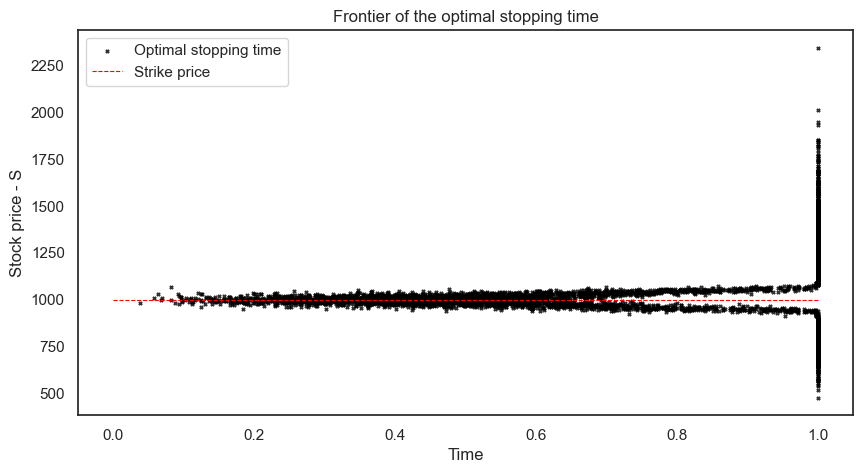

In [15]:
# Frontier S vs t_
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(t_[np.arange(0, n_paths), amm_stopping_time_index.astype(int)], S[np.arange(0, n_paths), amm_stopping_time_index.astype(int)], marker='x', s=5, color='black', alpha=0.8, label='Optimal stopping time')
ax.hlines(y=S_0, xmin=0, xmax=T, color='red', linestyle='--', linewidth=0.8, label='Strike price')

ax.set_xlabel('Time')
ax.set_ylabel('Stock price - S')
ax.set_title('Frontier of the optimal stopping time')

ax.legend()

plt.show()

In [ ]:
fig = plt.figure(figsize=(20, 15))

# 3D scatter plot
ax3d = fig.add_subplot(221, projection='3d')
scatter = ax3d.scatter(np.sum(amm_tau_matrix*t_, axis=1), np.sum(amm_tau_matrix*S, axis=1), np.sum(amm_tau_matrix*R, axis=1), c=np.sum(amm_tau_matrix*R, axis=1), s=5, marker='x')

ax3d.set_title('3D AMM Optimal Stopping Time')
ax3d.set_xlabel('Time')
ax3d.set_ylabel('Stock Price - S')
ax3d.set_zlabel('Fees collected - R')

ax3d.view_init(elev=40, azim=50)

plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(20, 15))

# 3D scatter plot
ax3d = fig.add_subplot(221, projection='3d')
scatter = ax3d.scatter(np.sum(amm_tau_matrix*t_, axis=1), np.sum(amm_tau_matrix*(S-Z), axis=1), np.sum(amm_tau_matrix*R, axis=1), c=np.sum(amm_tau_matrix*R, axis=1), s=5, marker='x')

ax3d.set_title('3D AMM Optimal Stopping Time')
ax3d.set_xlabel('Time')
ax3d.set_ylabel('Stock Price - S')
ax3d.set_zlabel('Fees collected - R')

ax3d.view_init(elev=40, azim=50)

plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(16, 12))

# 3D scatter plot
ax3d = fig.add_subplot(221, projection='3d')
scatter = ax3d.scatter(np.sum(amm_tau_matrix*t_, axis=1), np.sum(amm_tau_matrix*(S-Z), axis=1), np.sum(amm_tau_matrix*R, axis=1), c=np.sum(amm_tau_matrix*R, axis=1), s=5, marker='x')

ax3d.set_title('3D AMM Optimal Stopping Time')
ax3d.set_xlabel('Time')
ax3d.set_ylabel('Stock Price - S')
ax3d.set_zlabel('Fees collected - R')

ax3d.view_init(elev=40, azim=5)

# Projection on the XY plane (ignore z)
ax_xy = fig.add_subplot(222)
sc1 = ax_xy.scatter(np.sum(amm_tau_matrix*t_, axis=1), np.sum(amm_tau_matrix*(S-Z), axis=1), c='black', s=5, marker='x')
#ax_xy.hlines(y=S_0, xmin=0, xmax=T, color='red', linestyle='--', linewidth=0.8, label='Strike price')
ax_xy.set_title('XY Projection')
ax_xy.set_xlabel('Time')
ax_xy.set_ylabel('Stock Price - S')

ax_xy.legend()

# Projection on the XZ plane (ignore y)
ax_xz = fig.add_subplot(223)
sc2 = ax_xz.scatter(np.sum(amm_tau_matrix*t_, axis=1), np.sum(amm_tau_matrix*R, axis=1), c='black', s=5, marker='x')
ax_xz.set_title('XZ Projection')
ax_xz.set_xlabel('Time')
ax_xz.set_ylabel('Fees collected - R')

# Projection on the YZ plane (ignore x)
ax_yz = fig.add_subplot(224)
sc3 = ax_yz.scatter(np.sum(amm_tau_matrix*((S-Z)), axis=1), np.sum(amm_tau_matrix*R, axis=1), c='black', s=5, marker='x')
#ax_yz.vlines(x=S_0, ymin=0, ymax=np.max(np.sum(amm_tau_matrix*R, axis=1)), color='red', linestyle='--', linewidth=0.8, label='Strike price')
ax_yz.set_title('YZ Projection')
ax_yz.set_xlabel('Stock Price - S')
ax_yz.set_ylabel('Fees collected - R')

ax_yz.legend()

plt.tight_layout()
plt.show()


In [ ]:
nbr_path_plotted = 10
palette = sns.color_palette('tab10', nbr_path_plotted)

sns.set(style="white")

# Create the figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Create a second y-axis for the second curve
ax2 = ax1.twinx()

nbr_path_plotted = 10

for j in np.random.randint(0, high=amm_paths.shape[0], size=nbr_path_plotted, dtype=int):

    # Plot the first curve on the primary y-axis using Seaborn
    ax1.plot(t_[j,:], S[j,:], color=palette[j%nbr_path_plotted], linestyle='--', linewidth=1, alpha=0.5, label='S')

    # Plot the paths after the optimal stopping time in red
    ax2.plot(t_[j, int(amm_stopping_time_index[j])], amm_paths[j, int(amm_stopping_time_index[j])], color='black', linestyle='--', marker='x', linewidth=5, markersize=5, alpha=1)

    # Plot the second curve on the secondary y-axis using Seaborn
    ax2.step(t_[j,:], amm_paths[j,:], where='post', color=palette[j%nbr_path_plotted], linestyle='-', linewidth=1, alpha=0.7, label='amm_paths')

ax1.set_ylabel('S')#, color='blue')
ax2.set_ylabel('P_X + S*P_Y + R')#, color='red')

ax1.set_xlabel('Time')
ax1.set_title('Stopping time of the AMM process')

plt.show()

In [ ]:
for j in np.random.randint(0, high=amm_paths.shape[0], size=nbr_path_plotted, dtype=int):

    # Create the figure and primary axis
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Create a second y-axis for the second curve
    ax2 = ax1.twinx()

    # Plot the first curve on the primary y-axis using Seaborn
    ax1.plot(t_[j,:], S[j,:], color='red', linestyle='--', linewidth=1, alpha=0.5, label='S')

    # Plot the paths after the optimal stopping time in red
    ax2.plot(t_[j, int(amm_stopping_time_index[j])], amm_paths[j, int(amm_stopping_time_index[j])], color='black', linestyle='--', marker='x', linewidth=5, markersize=5, alpha=1)

    ax1.hlines(y=S_0, xmin=0, xmax=T, color='black', linestyle='--', linewidth=0.8, label='Strike price')

    # Plot the second curve on the secondary y-axis using Seaborn
    ax2.step(t_[j,:], amm_paths[j,:], where='post', color='blue', linestyle='-', linewidth=1, alpha=0.6, label='amm_paths')

    ax1.set_ylabel('S')#, color='blue')
    ax2.set_ylabel('P_X + S*P_Y + R')#, color='red')

    ax1.set_xlabel('Time')
    ax1.set_title('Stopping time of the AMM process')

    plt.show()

In [ ]:
j = 50

fig, ax = plt.subplots(figsize=(20, 8))

ax.step(t_[j,:], Z[j,:], linewidth=2, alpha=0.7, where='post', label='Z process')
ax.step(t_[j,:], S[j,:], linewidth=2, alpha=0.7, where='post', label='S process')

ax.set_title('S,Z processes - one path')
ax.set_xlabel('Time')
ax.set_ylabel('Value')

ax.legend()

plt.show()

In [ ]:
raise ValueError('Stop Here')

In [ ]:
############################################################################################################################################################################
# Draft US option pricing with Longstaff-Schwartz algorithm

# Initialisation
l = 2 # Degree of Laguerre/Standard polynomials // Dimension of the L2 basis
fitting_method = 'standard' # 'standard', 'laguerre', 'hermite'

V = np.zeros(shape=(n_paths, n_steps + 1))

# Define the terminal condition
V[:,-1] = g(S[:,-1], strike)

# Stopping time matrix
tau_matrix = np.zeros(shape=(n_paths, n_steps + 1))
tau_matrix[:, -1] = 1 # If never exercized, we consider that the option is exercised at maturity

# Loop for backward induction
for i in range(n_steps - 1, 0, -1):

    try:
        # Identify In The Money paths
        ITM = g(S[:, i], strike) > 0

        # Regression only on ITM paths
        if np.sum(ITM) > 0:    
            S_i_ITM = S[ITM, i]
            Y_i_ITM = V[ITM, i+1]*discount_factor

            if fitting_method == 'standard':
                P = np.polynomial.polynomial.Polynomial.fit(x=S_i_ITM, y=Y_i_ITM, deg=l)
            elif fitting_method == 'laguerre':
                P = np.polynomial.laguerre.Laguerre.fit(x=S_i_ITM, y=Y_i_ITM, deg=l)
            elif fitting_method == 'hermite':
                P = np.polynomial.hermite.Hermite.fit(x=S_i_ITM, y=Y_i_ITM, deg=l)

            stop_here_ITM_ti =  (g(S_i_ITM, strike) >= P(S_i_ITM)) # Stop here is applied on ITM paths
            V[ITM, i] = stop_here_ITM_ti*g(S_i_ITM, strike) + (1-stop_here_ITM_ti)*V[ITM, i+1]*discount_factor

            tau_matrix[ITM, i] = np.where(stop_here_ITM_ti, 1, 0)

        # Discount OTM paths
        V[~ITM, i] = V[~ITM, i+1]*discount_factor

    except Exception as e:
        print(f"Error at step {i} --> {e}")

# Get the first time the option is exercised for each path
stopping_time = np.argmax(tau_matrix,axis=1)

V0 = (1/n_paths)*np.sum(V[:,1]*discount_factor)
print(f"US {option_type} option price by Longstaff-Schwartz: {round(V0,4)}")  

# Plot
fig, ax = plt.subplots(figsize=(20, 8))

nbr_path_plotted = 100

for j in np.random.randint(0, high=n_paths, size=nbr_path_plotted, dtype=int):
        # Plot the paths before the optimal stopping time in green
        ax.plot(t_[j,:], S[j,:], 
                color='green', linestyle='--', linewidth=1, alpha=0.4)

        # Plot the paths after the optimal stopping time in red
        ax.plot(t_[j, int(stopping_time[j])], S[j, int(stopping_time[j])], 
                color='red', linestyle='--', marker='o', linewidth=1, markersize=3, alpha=1)

ax.set_xlim(left=0, right=T+10**(-2))
ax.hlines(y=strike, xmin=0, xmax=T, color='black', linestyle='--', linewidth=0.8, label='Strike price')

# Add title and labels
ax.set_title(f'Stopping time of diffusion process for {option_type}')
ax.set_xlabel('Time')
ax.set_ylabel('Stock price')

# Show the plot
plt.show()

############################################################################################################################################################################
# Draft for AMM path simulation
a0, a1, a2, a3 = 1, 30, 0, 10

ksi = 3

# Constant product function
phi_func = lambda x : c/x
d_phi_func = lambda x : -c/(x**2)

# Intensity functions
intensity_a = lambda Y, Z, S : np.maximum(a0, a1 + a2*Y + a3*(S-Z))
intensity_b = lambda Y, Z, S : np.maximum(a0, a1 + a2*Y + a3*(Z-S))

# Fees function
r_fees = lambda Y, Z : 1*Z + 0.1*Y

S, t_ = generate_BM_path(n_steps, **params)

X = np.zeros_like(S)
Y = np.zeros_like(S)
Z = np.zeros_like(S)
R = np.zeros_like(S) # Fees function

# Initialisation
Na, Nb = np.zeros_like(S), np.zeros_like(S)
Na[:, 0], Nb[:, 0] = 0, 0

X0 = 10**6 # USD
Y0 = 10**3 # USD

Y[:, 0] = Y0
X[:, 0] = X0
Z[:, 0] = X[:, 0]/Y[:, 0]

c = X0*Y0

# Generate path
for i in range(1, n_steps + 1):

    # Update Na and Nb: Jump times
    lambda_a = intensity_a(Y[:, i-1], Z[:, i-1], S[:, i])
    lambda_b = intensity_b(Y[:, i-1], Z[:, i-1], S[:, i])

    # If 1/lambda  equivalent to step_size, maybe more than one jump during the step
    u_a = np.random.uniform(0,1, size=n_paths)
    u_b = np.random.uniform(0,1, size=n_paths)

    dNa_i = (u_a <= lambda_a * step_size)*1
    dNb_i = (u_b <= lambda_b * step_size)*1

    Na[:, i] = dNa_i
    Nb[:, i] = dNb_i

    Y[:, i] = Y[:, i-1] + ksi*dNb_i - ksi*dNa_i
    X[:, i] = X[:, i-1] + (phi_func(Y[:, i-1]+ksi) - phi_func(Y[:, i-1]))*dNb_i + (phi_func(Y[:, i-1]-ksi) - phi_func(Y[:, i-1]))*dNa_i

    Z[:, i] = Z[:, i-1] + (-d_phi_func(Y[:, i-1]+ksi) + d_phi_func(Y[:, i-1]))*dNb_i + (-d_phi_func(Y[:, i-1]-ksi) + d_phi_func(Y[:, i-1]))*dNa_i

    R[:, i] += r_fees(Y[:, i-1], Z[:, i-1])*(dNa_i + dNb_i)

In [ ]:
# Draft class
class OptimalStoppingTime:
    def __init__(self):
        pass
    def solve(self):
        pass
class GeneratePath:
    def __init__(self):
        pass
    def generate_path(self):
        pass

class EDPSolver:# Take EDP as object
    def __init__(self):
        pass
    def euler(self):
        pass
    def longstaff_schwartz(self):
        pass